In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [5]:
admissions = pd.read_csv("admissions.csv")
fatalities = pd.read_csv("fatalities.csv")
prescriptions = pd.read_csv("prescriptions.csv")
smokers = pd.read_csv("smokers.csv")
metrics = pd.read_csv("metrics.csv")


In [6]:
admissions.head()


,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value
0,2014/15,All codes,All admissions,All admissions,Number of admissions,NaN,11011882
1,2014/15,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All diseases which can be caused by smoking,All diseases which can be caused by smoking,Number of admissions,NaN,1713330
2,2014/15,C00-D48,All cancers,All cancers,Number of admissions,NaN,1691035
3,2014/15,J00-J99,All respiratory diseases,All respiratory diseases,Number of admissions,NaN,611002
4,2014/15,I00-I99,All circulatory diseases,All circulatory diseases,Number of admissions,NaN,907157


In [7]:
fatalities.head()


,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value
0,2014,All codes,All deaths,All deaths,Number of observed deaths,NaN,459087
1,2014,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All deaths which can be caused by smoking,All deaths which can be caused by smoking,Number of observed deaths,NaN,235820
2,2014,C00-D48,All cancers,All cancers,Number of observed deaths,NaN,136312
3,2014,J00-J99,All respiratory diseases,All respiratory diseases,Number of observed deaths,NaN,61744
4,2014,I00-I99,All circulatory diseases,All circulatory diseases,Number of observed deaths,NaN,126101


In [8]:
admissions.info()
fatalities.info()
prescriptions.info()
smokers.info()
metrics.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2079 entries, 0 to 2078
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             2079 non-null   object
 1   ICD10 Code       2079 non-null   object
 2   ICD10 Diagnosis  2079 non-null   object
 3   Diagnosis Type   2079 non-null   object
 4   Metric           2079 non-null   object
 5   Sex              1386 non-null   object
 6   Value            2078 non-null   object
dtypes: object(7)
memory usage: 113.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1749 entries, 0 to 1748
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             1749 non-null   int64 
 1   ICD10 Code       1749 non-null   object
 2   ICD10 Diagnosis  1749 non-null   object
 3   Diagnosis Type   1749 non-null   object
 4   Metric           1749 non-null   object
 5   Sex              1166

In [9]:
admissions.isna().sum()
fatalities.isna().sum()
prescriptions.isna().sum()
smokers.isna().sum()
metrics.isna().sum()


Year                                                     0
Tobacco Price\nIndex                                     0
Retail Prices\nIndex                                     0
Tobacco Price Index Relative to Retail Price Index       0
Real Households' Disposable Income                       0
Affordability of Tobacco Index                           0
Household Expenditure on Tobacco                         5
Household Expenditure Total                              5
Expenditure on Tobacco as a Percentage of Expenditure    5
dtype: int64

In [10]:
metrics = metrics.fillna(method="ffill")


C:\Users\Admin\AppData\Local\Temp\ipykernel_25176\3550575620.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  metrics = metrics.fillna(method="ffill")


In [11]:
metrics.isna().sum()


Year                                                     0
Tobacco Price\nIndex                                     0
Retail Prices\nIndex                                     0
Tobacco Price Index Relative to Retail Price Index       0
Real Households' Disposable Income                       0
Affordability of Tobacco Index                           0
Household Expenditure on Tobacco                         0
Household Expenditure Total                              0
Expenditure on Tobacco as a Percentage of Expenditure    0
dtype: int64

In [12]:
# Admissions
admissions["Year_Clean"] = admissions["Year"].astype(str).str[:4].astype(int)

# Prescriptions
prescriptions["Year_Clean"] = prescriptions["Year"].astype(str).str[:4].astype(int)


In [13]:
admissions[["Year", "Year_Clean"]].head()


,Year,Year_Clean
0,2014/15,2014
1,2014/15,2014
2,2014/15,2014
3,2014/15,2014
4,2014/15,2014


In [14]:
prescriptions[["Year", "Year_Clean"]].head()


,Year,Year_Clean
0,2014/15,2014
1,2013/14,2013
2,2012/13,2012
3,2011/12,2011
4,2010/11,2010


In [15]:
smokers["Year"].head()


0    1974
1    1976
2    1978
3    1980
4    1982
Name: Year, dtype: int64

In [16]:
admissions["Value"] = pd.to_numeric(admissions["Value"], errors="coerce")


In [17]:
fatalities["Value"] = pd.to_numeric(fatalities["Value"], errors="coerce")


In [18]:
prescriptions["All Pharmacotherapy Prescriptions"] = pd.to_numeric(
    prescriptions["All Pharmacotherapy Prescriptions"],
    errors="coerce"
)


In [19]:
for name, df in {
    "admissions": admissions,
    "fatalities": fatalities,
    "prescriptions": prescriptions,
    "smokers": smokers,
    "metrics": metrics
}.items():
    print(name, "→", df.shape)


admissions → (2079, 8)
fatalities → (1749, 7)
prescriptions → (11, 10)
smokers → (84, 9)
metrics → (36, 9)


In [20]:
print("Admissions shape:", admissions.shape)
print("Fatalities shape:", fatalities.shape)
print("Prescriptions shape:", prescriptions.shape)
print("Smokers shape:", smokers.shape)
print("Metrics shape:", metrics.shape)


Admissions shape: (2079, 8)
Fatalities shape: (1749, 7)
Prescriptions shape: (11, 10)
Smokers shape: (84, 9)
Metrics shape: (36, 9)


In [21]:
print("Admissions years:", admissions["Year_Clean"].min(), "-", admissions["Year_Clean"].max())
print("Prescriptions years:", prescriptions["Year_Clean"].min(), "-", prescriptions["Year_Clean"].max())
print("Fatalities years:", fatalities["Year"].min(), "-", fatalities["Year"].max())
print("Smokers years:", smokers["Year"].min(), "-", smokers["Year"].max())
print("Metrics years:", metrics["Year"].min(), "-", metrics["Year"].max())


Admissions years: 2004 - 2014
Prescriptions years: 2004 - 2014
Fatalities years: 2004 - 2014
Smokers years: 1974 - 2014
Metrics years: 1980 - 2015


In [22]:
adm_yearly = (
    admissions.groupby("Year_Clean")["Value"]
    .sum()
    .reset_index(name="Total Admissions")
)


In [23]:
fat_yearly = (
    fatalities.groupby("Year")["Value"]
    .sum()
    .reset_index(name="Total Fatalities")
)


In [24]:
pres_yearly = (
    prescriptions.groupby("Year_Clean")["All Pharmacotherapy Prescriptions"]
    .sum()
    .reset_index(name="Total Prescriptions")
)


In [26]:
# First merge - specify suffixes to avoid duplicate column names
master = adm_yearly.merge(
    fat_yearly,
    left_on="Year_Clean",
    right_on="Year",
    how="outer",
    suffixes=('', '_fat')  # This will add '_fat' suffix to duplicate columns from fat_yearly
)

# Drop the duplicate Year column before the next merge
master = master.drop(columns=["Year"])  # Keep only Year_Clean

# Second merge
master = master.merge(
    pres_yearly,
    on="Year_Clean",
    how="outer"
)

# Rename and sort
master = master.rename(columns={"Year_Clean": "Year"})
master = master.sort_values("Year")
master.head()

,Year,Total Admissions,Total Fatalities,Total Prescriptions
0,2004,30552501.0,3419012.0,2044
1,2005,31875961.0,3378668.0,2205
2,2006,32549797.0,3262592.0,2079
3,2007,33474110.0,3232496.0,2475
4,2008,43150397.0,3259694.0,2263


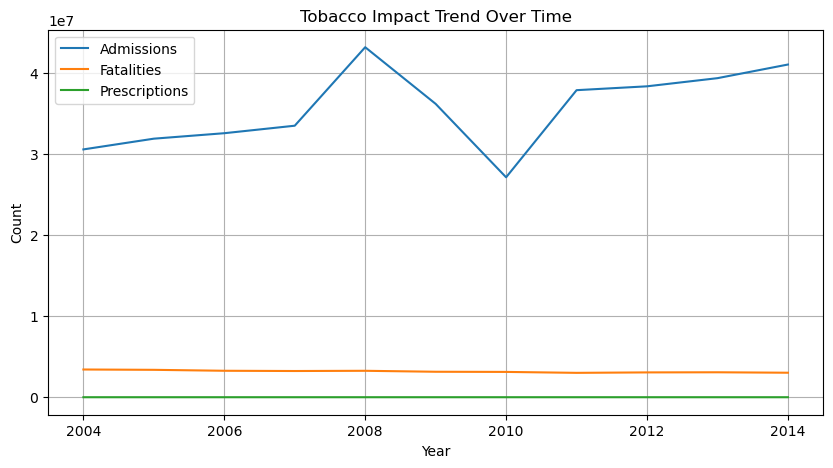

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(master["Year"], master["Total Admissions"], label="Admissions")
plt.plot(master["Year"], master["Total Fatalities"], label="Fatalities")
plt.plot(master["Year"], master["Total Prescriptions"], label="Prescriptions")

plt.title("Tobacco Impact Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.show()


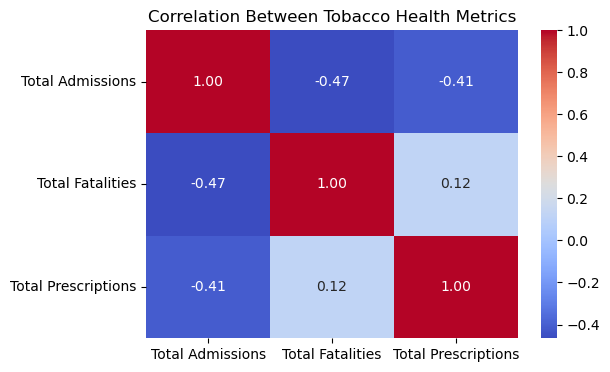

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

corr = master[[
    "Total Admissions",
    "Total Fatalities",
    "Total Prescriptions"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Tobacco Health Metrics")
plt.show()


In [29]:
smoking_yearly = (
    smokers.groupby("Year")["16 and Over"]
    .mean()
    .reset_index(name="Avg Smoking Rate")
)

smoking_yearly.head()


,Year,Avg Smoking Rate
0,1974,46.000000
1,1976,42.000000
2,1978,40.333333
3,1980,39.333333
4,1982,35.333333


In [30]:
master2 = master.merge(
    smoking_yearly,
    on="Year",
    how="left"
)

master2.head()


,Year,Total Admissions,Total Fatalities,Total Prescriptions,Avg Smoking Rate
0,2004,30552501.0,3419012.0,2044,24.666667
1,2005,31875961.0,3378668.0,2205,24.000000
2,2006,32549797.0,3262592.0,2079,22.000000
3,2007,33474110.0,3232496.0,2475,21.000000
4,2008,43150397.0,3259694.0,2263,21.333333


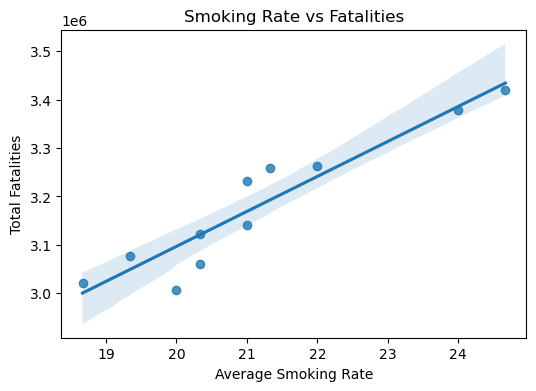

In [31]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=master2,
    x="Avg Smoking Rate",
    y="Total Fatalities"
)

plt.title("Smoking Rate vs Fatalities")
plt.xlabel("Average Smoking Rate")
plt.ylabel("Total Fatalities")

plt.show()


In [32]:
corr_value = master2["Avg Smoking Rate"].corr(master2["Total Fatalities"])

print("Correlation between Smoking Rate and Fatalities:", round(corr_value, 3))


Correlation between Smoking Rate and Fatalities: 0.94


In [33]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = master2[["Avg Smoking Rate"]].dropna()
y = master2.loc[X.index, "Total Fatalities"]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)
print("R-squared:", round(r2, 3))


R-squared: 0.884
